# Part 2 — Community detection and tissue niches

**Question.** Does unsupervised community detection on the spatial cell graph recover biologically interpretable tissue niches — that is, regions of distinctive cell-type composition that recur across patients?

**Approach.**

- **Per-sample Leiden** on the spatial graph (weighted by `1 - mean_neighbor_radius`), restricted to each sample's giant connected component. Small components and isolates are excluded from niche analysis (they cannot meaningfully participate in cross-sample alignment).
- **Composition-based cross-sample alignment**: each community is represented by its 8-d cell-type composition vector. Hierarchical clustering of these vectors across all communities-from-all-samples identifies recurrent "niche types."
- **Pure spatial-graph** analysis (no expression-modulated edge weights in the headline). An expression-aware variant may be explored as an extension.

**Notebook structure.**

1. §0 Setup + Part 1 results
2. §1 Resolution sweep on representative samples → choose γ
3. §2 Per-sample Leiden on all 112 samples, save labels
4. §3 Per-sample community characterization
5. §4 Cross-sample composition-based alignment → recurrent niches
6. §5 Niche visualization on representative samples
7. §6 Niche stability across patient folds (train vs val vs test)
8. §7 Summary

## 0. Setup

Imports, path resolution, and loading of artifacts from Part 1 (free-tier topology table, expensive-tier per-sample summary, sample bins). `leidenalg` is a new dependency for this notebook; we verify it imports cleanly.

In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# allow importing from src/ regardless of where the notebook was launched
ROOT = Path.cwd()
if (ROOT / "src").is_dir():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").is_dir():
    sys.path.insert(0, str(ROOT.parent / "src"))

import data_io
import graph_construction
importlib.reload(data_io)
importlib.reload(graph_construction)

# New for Part 2
import igraph as ig
import leidenalg as la
print(f"igraph version:    {ig.__version__}")
print(f"leidenalg version: {la.version}")

CACHE_DIR = "cache" if (ROOT / "cache").is_dir() else "../cache"

# Load globals (~600 MB)
G = data_io.load_global(CACHE_DIR)
print(f"\nglobal arrays loaded from {CACHE_DIR}")
print(f"  n_cells:    {G.n_cells:,}")
print(f"  n_patients: {len(np.unique(G.patient))}")
print(f"  n_samples:  {len(np.unique(G.sample))}")

igraph version:    1.0.0
leidenalg version: 0.12.0

global arrays loaded from ../cache
  n_cells:    8,065,561
  n_patients: 56
  n_samples:  112


In [2]:
# Load Part 1 outputs
topo_cache = Path(CACHE_DIR) / "topology"

free_tier = pd.read_parquet(topo_cache / "free_tier.parquet")
expensive = pd.read_parquet(topo_cache / "expensive_tier.parquet")

print(f"free_tier:  {free_tier.shape}  ({len(free_tier)} samples, {free_tier.shape[1]} metrics)")
print(f"expensive:  {expensive.shape}  ({len(expensive)} samples)")

# Sanity glance — index matches the 112 samples we expect
assert sorted(free_tier.index) == sorted(int(s) for s in np.unique(G.sample))
print(f"\nfree_tier index matches global sample IDs: ✓")
print(f"anomalies flagged in free_tier: {free_tier.index[free_tier.is_anomaly].tolist()}")

free_tier:  (112, 22)  (112 samples, 22 metrics)
expensive:  (10, 13)  (10 samples)

free_tier index matches global sample IDs: ✓
anomalies flagged in free_tier: [87, 107]


In [3]:
# Load the patient split (for §6 — niche stability across folds)
from splits import load_splits
split = load_splits(f"{CACHE_DIR}/splits/patient_split.json")
print(f"patient split (seed={split.seed}, n_trials={split.n_trials:,})")
print(f"  train ({len(split.train):2d}): {split.train[:10]}{'...' if len(split.train) > 10 else ''}")
print(f"  val   ({len(split.val):2d}): {split.val}")
print(f"  test  ({len(split.test):2d}): {split.test}")
print(f"  balance score: {split.balance_score:.4f}")

# Build patient -> fold mapping (handy for later)
patient_fold = {}
for p in split.train: patient_fold[p] = "train"
for p in split.val:   patient_fold[p] = "val"
for p in split.test:  patient_fold[p] = "test"

patient split (seed=42, n_trials=100,000)
  train (40): [1, 2, 3, 4, 5, 6, 7, 8, 9, 11]...
  val   ( 8): [10, 15, 16, 22, 30, 38, 39, 54]
  test  ( 8): [0, 21, 26, 28, 34, 40, 45, 51]
  balance score: 0.0635


In [4]:
# Set up a working cache directory for Part 2 outputs
comm_cache = Path(CACHE_DIR) / "communities"
comm_cache.mkdir(exist_ok=True, parents=True)
print(f"Part 2 output directory: {comm_cache}")

Part 2 output directory: ../cache/communities


## 1. Resolution sweep

Leiden's resolution parameter γ controls niche granularity. Higher γ → more, smaller niches; lower γ → fewer, larger ones. We sweep γ ∈ {0.3, 0.5, 0.7, 1.0, 1.5, 2.0} on three compact samples (4, 2, 55) to pick a value producing ~5-20 medium-sized communities per giant component.

Communities are detected on the **giant connected component only**, with edges weighted by `1 - mean_neighbor_radius` (closer cells contribute more strongly).

In [5]:
# Three representative compact samples (>97% giant frac in Part 1)
SWEEP_SAMPLES = [4, 2, 55]
GAMMAS = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
LEIDEN_SEED = 42

def leiden_on_giant(sg, gamma, seed=LEIDEN_SEED):
    """Run Leiden on the giant component of a SpatialGraph (weighted).
    Returns: (community_labels for ALL nodes; -1 = not in giant comp),
             igraph subgraph of the giant component,
             local-to-global node id map for the subgraph.
    """
    g = graph_construction.to_igraph(sg)
    comps = g.connected_components(mode="weak")
    sizes = np.array(comps.sizes())
    giant_idx = int(sizes.argmax())
    membership = np.array(comps.membership)
    giant_node_ids = np.where(membership == giant_idx)[0]
    sub = g.subgraph(giant_node_ids.tolist())

    # Weighted partition. The edge attribute "weight" is set by to_igraph
    # when the SpatialGraph was built with weighted=True.
    partition = la.find_partition(
        sub,
        la.RBConfigurationVertexPartition,
        weights="weight" if "weight" in sub.edge_attributes() else None,
        resolution_parameter=gamma,
        seed=seed,
    )
    sub_labels = np.array(partition.membership, dtype=np.int32)

    # Map back to full-sample local node space (-1 for non-giant cells)
    full_labels = np.full(sg.n_nodes, -1, dtype=np.int32)
    full_labels[giant_node_ids] = sub_labels
    return full_labels, sub, giant_node_ids


# Sweep
import time
results = []  # one row per (sample, gamma)
for s in SWEEP_SAMPLES:
    sg_s = graph_construction.build_for_sample(s, global_arrays=G, weighted=True)
    n_giant = (free_tier.loc[s, "largest_component_size"])
    for gamma in GAMMAS:
        t0 = time.time()
        full_labels, sub, _ = leiden_on_giant(sg_s, gamma)
        elapsed = time.time() - t0
        sub_labels = full_labels[full_labels >= 0]
        sizes = np.bincount(sub_labels)
        results.append({
            "sample_id": s,
            "gamma": gamma,
            "n_communities": int(sizes.size),
            "largest_community_frac": float(sizes.max() / sizes.sum()),
            "n_communities_ge_100": int((sizes >= 100).sum()),
            "n_communities_ge_500": int((sizes >= 500).sum()),
            "median_community_size": int(np.median(sizes)),
            "modularity": float(la.RBConfigurationVertexPartition(
                sub,
                weights="weight" if "weight" in sub.edge_attributes() else None,
                resolution_parameter=gamma,
                initial_membership=sub_labels.tolist(),
            ).quality()),
            "time_s": round(elapsed, 1),
        })
        print(f"  sample {s}, γ={gamma}: n_comm={sizes.size:>4}, "
              f"largest={sizes.max()/sizes.sum():.2%}, "
              f"≥100: {(sizes >= 100).sum():>3}, time={elapsed:.1f}s")

sweep_df = pd.DataFrame(results)
print()
print(sweep_df.pivot(index="gamma", columns="sample_id", values="n_communities_ge_100"))

  sample 4, γ=0.3: n_comm=  55, largest=3.64%, ≥100:  48, time=1.2s
  sample 4, γ=0.5: n_comm=  75, largest=2.98%, ≥100:  67, time=1.2s
  sample 4, γ=0.7: n_comm=  86, largest=2.71%, ≥100:  77, time=1.2s
  sample 4, γ=1.0: n_comm= 106, largest=2.28%, ≥100:  93, time=1.2s
  sample 4, γ=1.5: n_comm= 129, largest=1.56%, ≥100: 110, time=1.2s
  sample 4, γ=2.0: n_comm= 149, largest=1.72%, ≥100: 117, time=1.2s
  sample 2, γ=0.3: n_comm=  49, largest=4.65%, ≥100:  44, time=2.1s
  sample 2, γ=0.5: n_comm=  69, largest=3.45%, ≥100:  64, time=2.3s
  sample 2, γ=0.7: n_comm=  85, largest=2.56%, ≥100:  76, time=2.2s
  sample 2, γ=1.0: n_comm= 104, largest=2.14%, ≥100:  90, time=2.2s
  sample 2, γ=1.5: n_comm= 130, largest=1.71%, ≥100: 116, time=2.2s
  sample 2, γ=2.0: n_comm= 147, largest=1.64%, ≥100: 128, time=2.2s
  sample 55, γ=0.3: n_comm= 100, largest=2.96%, ≥100:  93, time=9.4s
  sample 55, γ=0.5: n_comm= 141, largest=2.16%, ≥100: 123, time=9.7s
  sample 55, γ=0.7: n_comm= 160, largest=1.87%

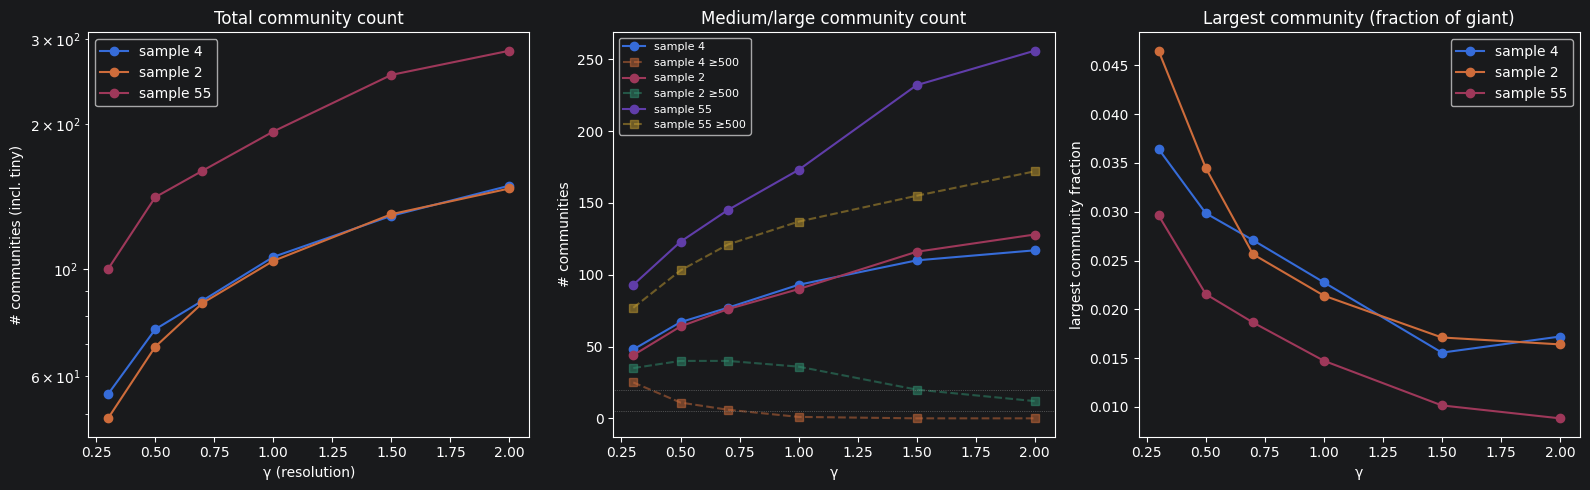

 sample_id  gamma  n_communities  largest_community_frac  n_communities_ge_100  n_communities_ge_500  median_community_size    modularity  time_s
         4    0.3             55                0.036435                    48                    25                    432  88780.640679     1.2
         4    0.5             75                0.029848                    67                    11                    293  88404.036227     1.2
         4    0.7             86                0.027089                    77                     6                    255  88127.572729     1.2
         4    1.0            106                0.022767                    93                     1                    226  87790.355897     1.2
         4    1.5            129                0.015562                   110                     0                    188  87310.951305     1.2
         4    2.0            149                0.017209                   117                     0                    163 

In [6]:
# Visualize the sweep

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
for s in SWEEP_SAMPLES:
    sub = sweep_df[sweep_df.sample_id == s]
    ax.plot(sub.gamma, sub.n_communities, marker="o", label=f"sample {s}")
ax.set_xlabel("γ (resolution)")
ax.set_ylabel("# communities (incl. tiny)")
ax.set_title("Total community count")
ax.legend()
ax.set_yscale("log")

ax = axes[1]
for s in SWEEP_SAMPLES:
    sub = sweep_df[sweep_df.sample_id == s]
    ax.plot(sub.gamma, sub.n_communities_ge_100, marker="o", label=f"sample {s}")
    ax.plot(sub.gamma, sub.n_communities_ge_500, marker="s", linestyle="--",
            label=f"sample {s} ≥500", alpha=0.5)
ax.set_xlabel("γ")
ax.set_ylabel("# communities")
ax.set_title("Medium/large community count")
ax.legend(fontsize=8)
ax.axhline(5, color="gray", linewidth=0.5, linestyle=":")
ax.axhline(20, color="gray", linewidth=0.5, linestyle=":")

ax = axes[2]
for s in SWEEP_SAMPLES:
    sub = sweep_df[sweep_df.sample_id == s]
    ax.plot(sub.gamma, sub.largest_community_frac, marker="o", label=f"sample {s}")
ax.set_xlabel("γ")
ax.set_ylabel("largest community fraction")
ax.set_title("Largest community (fraction of giant)")
ax.legend()

plt.tight_layout()
plt.show()
print(sweep_df.to_string(index=False))

## Sanity check: do the communities look spatially coherent?

Before committing to γ=0.5 for the full pipeline, visualize the communities on sample 2's spatial layout. We want to see contiguous spatial patches per community — if communities are scattered (one community everywhere, no spatial coherence), Leiden isn't doing what we'd want for niche detection.

sample 2 at γ=0.5: 69 communities in the giant
  largest: 1,463 cells  (3.45%)
  median:  572 cells
  ≥100:    64
  ≥500:    40


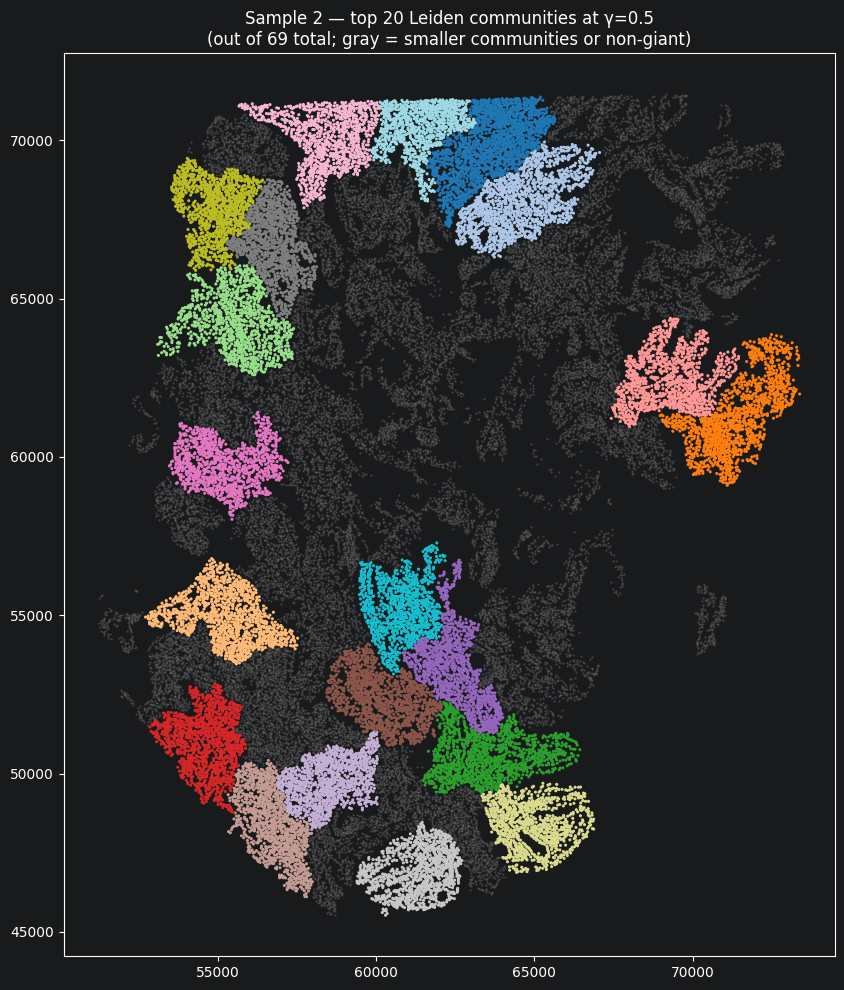

In [7]:
# Run Leiden at γ=0.5 on sample 2, visualize spatially
GAMMA_TEST = 0.5
s_test = 2
sg_test = graph_construction.build_for_sample(s_test, global_arrays=G, weighted=True)
labels_test, _, _ = leiden_on_giant(sg_test, GAMMA_TEST)

pos_test = G.positions[sg_test.global_idxs]

# How many communities are there, what are their sizes?
giant_labels = labels_test[labels_test >= 0]
sizes = np.bincount(giant_labels)
print(f"sample {s_test} at γ={GAMMA_TEST}: {len(sizes)} communities in the giant")
print(f"  largest: {sizes.max():,} cells  ({100*sizes.max()/sizes.sum():.2f}%)")
print(f"  median:  {int(np.median(sizes)):,} cells")
print(f"  ≥100:    {(sizes >= 100).sum()}")
print(f"  ≥500:    {(sizes >= 500).sum()}")

# Visualization: color cells by community for the top-20 largest communities,
# everything else gray. Twenty colors keeps the figure legible.
N_TOP = 20
size_order = sizes.argsort()[::-1]
top_comms = set(size_order[:N_TOP])
node_color_id = np.full_like(labels_test, fill_value=-1)
for new_id, comm in enumerate(size_order[:N_TOP]):
    node_color_id[labels_test == comm] = new_id

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
# Background: gray = non-giant or non-top community
mask_bg = node_color_id < 0
ax.scatter(pos_test[mask_bg, 0], pos_test[mask_bg, 1], s=0.5, c="gray", alpha=0.3)
# Foreground: colored by community
mask_fg = node_color_id >= 0
sc = ax.scatter(pos_test[mask_fg, 0], pos_test[mask_fg, 1],
                s=1.5, c=node_color_id[mask_fg], cmap="tab20")
ax.set_aspect("equal")
ax.set_title(f"Sample {s_test} — top {N_TOP} Leiden communities at γ={GAMMA_TEST}\n"
             f"(out of {len(sizes)} total; gray = smaller communities or non-giant)")
plt.tight_layout()
plt.show()

## 2. Per-sample Leiden across all 112 samples

We run Leiden at γ=0.5 on each sample's giant component (weighted edges, seed 42 for reproducibility). Output: a global `(N,) int16` array of per-cell community labels (-1 = not in giant). Saved to `cache/communities/leiden_labels.npy`.

Total expected runtime: ~10-20 min.

In [8]:
from tqdm.auto import tqdm

GAMMA = 0.5
LEIDEN_SEED = 42

# Global per-cell community labels (init to -1)
global_labels = np.full(G.n_cells, -1, dtype=np.int16)

# Per-sample summary as we go
sample_summary = []

t_start = time.time()
for s in tqdm(sorted(int(x) for x in np.unique(G.sample)), desc="Leiden"):
    sg = graph_construction.build_for_sample(s, global_arrays=G, weighted=True)
    labels_local, _, _ = leiden_on_giant(sg, GAMMA, seed=LEIDEN_SEED)

    # Map local node IDs -> global cell IDs and store
    global_labels[sg.global_idxs] = labels_local.astype(np.int16)

    sub_labels = labels_local[labels_local >= 0]
    n_comm = int(sub_labels.max()) + 1 if len(sub_labels) else 0
    sizes = np.bincount(sub_labels, minlength=n_comm)
    sample_summary.append({
        "sample_id": s,
        "n_giant_cells": int(len(sub_labels)),
        "n_communities": n_comm,
        "n_communities_ge_100": int((sizes >= 100).sum()),
        "median_comm_size": int(np.median(sizes)) if n_comm else 0,
        "largest_comm_frac": float(sizes.max() / sizes.sum()) if n_comm else 0.0,
    })

elapsed = time.time() - t_start
print(f"\ndone in {elapsed/60:.1f} min")
print(f"global_labels: shape={global_labels.shape}, dtype={global_labels.dtype}")
print(f"  cells in any community (-1 excluded): {(global_labels >= 0).sum():,} "
      f"({100*(global_labels >= 0).mean():.1f}%)")

/home/matteo.doria/Desktop/ASLCD/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Leiden: 100%|██████████| 112/112 [05:39<00:00,  3.03s/it]


done in 5.7 min
global_labels: shape=(8065561,), dtype=int16
  cells in any community (-1 excluded): 6,301,678 (78.1%)


In [9]:
# Persist
labels_path = comm_cache / "leiden_labels.npy"
np.save(labels_path, global_labels)
print(f"saved to {labels_path}")
print(f"file size: {labels_path.stat().st_size / 1e6:.1f} MB")

# Per-sample summary table
sample_summary_df = pd.DataFrame(sample_summary).set_index("sample_id")
sample_summary_path = comm_cache / "per_sample_summary.parquet"
sample_summary_df.to_parquet(sample_summary_path)
print(f"per-sample summary saved to {sample_summary_path}")
print()
print(sample_summary_df.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2))

saved to ../cache/communities/leiden_labels.npy
file size: 16.1 MB
per-sample summary saved to ../cache/communities/per_sample_summary.parquet

       n_giant_cells  n_communities  n_communities_ge_100  median_comm_size  \
count         112.00         112.00                112.00            112.00   
mean        56264.98         102.90                 84.44            443.29   
std         57975.61          66.04                 55.53            356.96   
min            53.00           7.00                  0.00              8.00   
5%           2810.60          26.75                 13.20             85.10   
25%         15656.50          55.75                 46.75            205.75   
50%         27301.50          76.50                 64.00            359.00   
75%         91449.25         148.25                125.25            532.00   
95%        184149.85         221.00                187.15           1163.60   
max        223774.00         315.00                257.00         

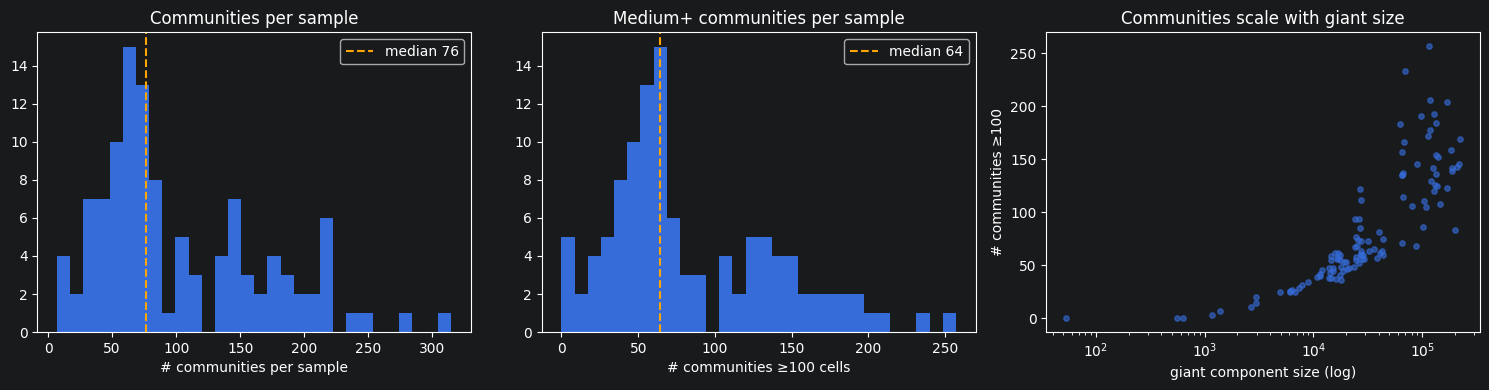

In [10]:
# A quick cross-sample look at community counts and sizes

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sample_summary_df["n_communities"], bins=30)
axes[0].set_xlabel("# communities per sample")
axes[0].axvline(sample_summary_df["n_communities"].median(), color="orange",
                linestyle="--", label=f"median {sample_summary_df['n_communities'].median():.0f}")
axes[0].legend()
axes[0].set_title("Communities per sample")

axes[1].hist(sample_summary_df["n_communities_ge_100"], bins=30)
axes[1].set_xlabel("# communities ≥100 cells")
axes[1].axvline(sample_summary_df["n_communities_ge_100"].median(), color="orange",
                linestyle="--", label=f"median {sample_summary_df['n_communities_ge_100'].median():.0f}")
axes[1].legend()
axes[1].set_title("Medium+ communities per sample")

axes[2].scatter(sample_summary_df["n_giant_cells"], sample_summary_df["n_communities_ge_100"],
                s=15, alpha=0.6)
axes[2].set_xscale("log")
axes[2].set_xlabel("giant component size (log)")
axes[2].set_ylabel("# communities ≥100")
axes[2].set_title("Communities scale with giant size")

plt.tight_layout()
plt.show()

highest largest_comm_frac sample: s107
  is_anomaly in Part 1: True
  giant cells: 53
  n_communities: 7
  largest_community_frac (Part 1, on raw graph): 0.054



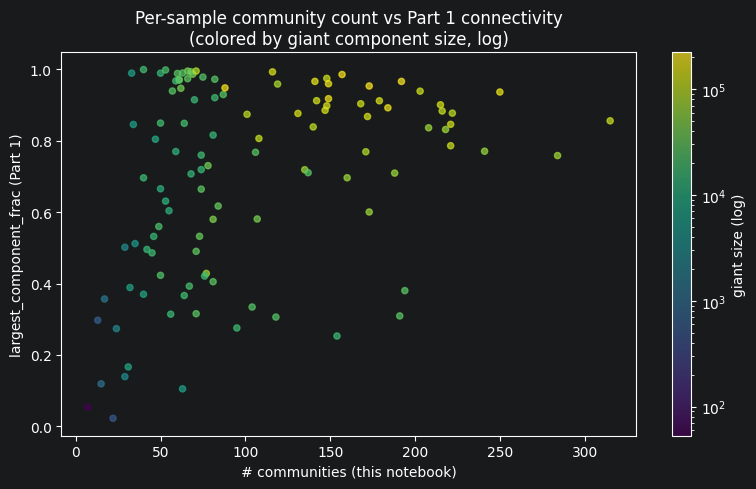

Spearman ρ(n_communities, giant_size): 0.825


In [11]:
# Quick sanity: where do the outliers and bimodality come from?

# Which sample has largest_comm_frac=0.25?
outlier_id = sample_summary_df["largest_comm_frac"].idxmax()
print(f"highest largest_comm_frac sample: s{outlier_id}")
print(f"  is_anomaly in Part 1: {free_tier.loc[outlier_id, 'is_anomaly']}")
print(f"  giant cells: {sample_summary_df.loc[outlier_id, 'n_giant_cells']}")
print(f"  n_communities: {sample_summary_df.loc[outlier_id, 'n_communities']}")
print(f"  largest_community_frac (Part 1, on raw graph): "
      f"{free_tier.loc[outlier_id, 'largest_component_frac']:.3f}")
print()

# Bimodality check: does n_communities correlate with giant size from Part 1?
joined = sample_summary_df.join(free_tier[["n_nodes", "largest_component_frac", "is_anomaly"]],
                                rsuffix="_p1")
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
colors = joined["largest_component_frac"]
sc = ax.scatter(joined["n_communities"], joined["largest_component_frac"],
                c=joined["n_giant_cells"], s=20, alpha=0.7,
                cmap="viridis", norm=plt.matplotlib.colors.LogNorm())
ax.set_xlabel("# communities (this notebook)")
ax.set_ylabel("largest_component_frac (Part 1)")
ax.set_title("Per-sample community count vs Part 1 connectivity\n"
             "(colored by giant component size, log)")
plt.colorbar(sc, ax=ax, label="giant size (log)")
plt.tight_layout()
plt.show()

# Spearman correlation
r_spearman = joined[["n_communities", "n_giant_cells"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman ρ(n_communities, giant_size): {r_spearman:.3f}")

## 3. Per-community characterization

For every community in every sample, compute:

- **Size** (number of cells)
- **Cell-type composition** (fraction of each of the 8 classes)
- **Spatial extent** (centroid x/y, bounding-box width/height, area)
- **Sample / patient / patient-fold metadata** for downstream stratification

Stored as a single DataFrame indexed by `(sample_id, community_id)`.

In [12]:
# Build per-community feature table

n_classes = 8
rows = []

for s in sorted(int(x) for x in np.unique(G.sample)):
    sample_cell_mask = G.sample == s
    sample_global_idxs = np.where(sample_cell_mask)[0]
    sample_labels = global_labels[sample_global_idxs]
    sample_cell_types = G.cell_type[sample_global_idxs]
    sample_pos = G.positions[sample_global_idxs]

    is_anomaly = bool(free_tier.loc[s, "is_anomaly"])
    patient = int(G.patient[sample_global_idxs[0]])
    fold = patient_fold[patient]

    for c in range(int(sample_labels.max()) + 1 if (sample_labels >= 0).any() else 0):
        mask = sample_labels == c
        n = int(mask.sum())
        if n == 0:
            continue
        ct = sample_cell_types[mask]
        comp = np.bincount(ct, minlength=n_classes) / n
        pos = sample_pos[mask]
        row = {
            "sample_id": s,
            "community_id": int(c),
            "patient": patient,
            "fold": fold,
            "is_sample_anomaly": is_anomaly,
            "n_cells": n,
            "centroid_x": float(pos[:, 0].mean()),
            "centroid_y": float(pos[:, 1].mean()),
            "bbox_w": float(pos[:, 0].max() - pos[:, 0].min()),
            "bbox_h": float(pos[:, 1].max() - pos[:, 1].min()),
        }
        for k in range(n_classes):
            row[f"frac_class_{k}"] = float(comp[k])
        rows.append(row)

communities_df = pd.DataFrame(rows)
communities_df["bbox_area"] = communities_df["bbox_w"] * communities_df["bbox_h"]
# Effective density in pixels-per-cell (smaller = tighter packing)
communities_df["area_per_cell"] = communities_df["bbox_area"] / communities_df["n_cells"]

print(f"total communities across cohort: {len(communities_df):,}")
print(f"  from anomaly samples:           {communities_df['is_sample_anomaly'].sum()}")
print(f"  non-anomaly communities:        {(~communities_df['is_sample_anomaly']).sum():,}")
print()
print(communities_df.head(3).T)

total communities across cohort: 11,525
  from anomaly samples:           29
  non-anomaly communities:        11,496

                              0             1             2
sample_id                     0             0             0
community_id                  0             1             2
patient                      37            37            37
fold                      train         train         train
is_sample_anomaly         False         False         False
n_cells                     832           814           795
centroid_x         18487.441406  23125.765625  28629.242188
centroid_y         10864.696289  19189.050781  22247.673828
bbox_w                   3014.0        5679.0        4104.0
bbox_h                   3651.0        2201.0        3046.0
frac_class_0           0.140625      0.028256      0.095597
frac_class_1           0.121394      0.111794      0.115723
frac_class_2           0.110577      0.206388      0.228931
frac_class_3           0.299279      0.20

In [13]:
# Persist
communities_path = comm_cache / "communities_table.parquet"
communities_df.to_parquet(communities_path)
print(f"saved to {communities_path} ({communities_path.stat().st_size / 1e6:.1f} MB)")

saved to ../cache/communities/communities_table.parquet (1.0 MB)


In [14]:
# Cohort-level summary

# Filter out anomaly-sample communities and very small ones for visualization
core = communities_df[~communities_df.is_sample_anomaly].copy()
core_100 = core[core.n_cells >= 100]
print(f"All communities: {len(communities_df):,}")
print(f"Excluding anomaly samples: {len(core):,}")
print(f"Of these, ≥100 cells: {len(core_100):,}")
print()
print("Size distribution (non-anomaly, all sizes):")
print(core["n_cells"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(1))

All communities: 11,525
Excluding anomaly samples: 11,496
Of these, ≥100 cells: 9,457

Size distribution (non-anomaly, all sizes):
count    11496.0
mean       548.1
std        587.5
min          1.0
5%          19.0
25%        150.0
50%        355.0
75%        727.0
95%       1767.8
max       5189.0
Name: n_cells, dtype: float64


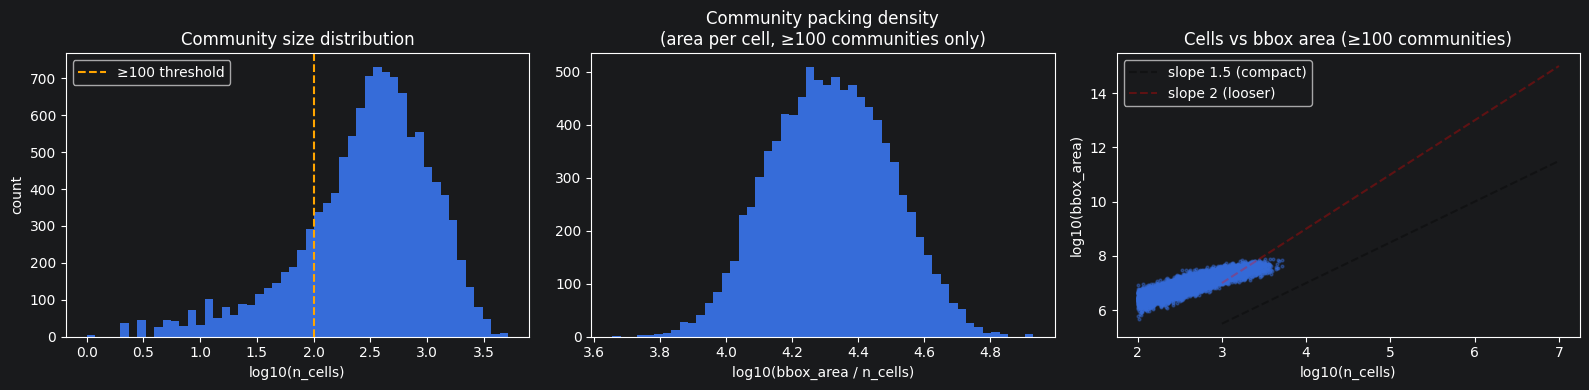

In [15]:
# Visualize: community size distribution + spatial extent

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Size, log scale
axes[0].hist(np.log10(core["n_cells"]), bins=50)
axes[0].set_xlabel("log10(n_cells)")
axes[0].set_ylabel("count")
axes[0].axvline(np.log10(100), color="orange", linestyle="--", label="≥100 threshold")
axes[0].set_title("Community size distribution")
axes[0].legend()

# Density (area_per_cell)
axes[1].hist(np.log10(core_100["area_per_cell"]), bins=50)
axes[1].set_xlabel("log10(bbox_area / n_cells)")
axes[1].set_title("Community packing density\n(area per cell, ≥100 communities only)")

# n_cells vs bbox_area (should be a tight relationship for compact niches)
sc = axes[2].scatter(np.log10(core_100["n_cells"]), np.log10(core_100["bbox_area"]),
                     s=4, alpha=0.4)
axes[2].set_xlabel("log10(n_cells)")
axes[2].set_ylabel("log10(bbox_area)")
axes[2].set_title("Cells vs bbox area (≥100 communities)")
# add y=x reference
lim = [3, 7]
axes[2].plot(lim, [l * 1.5 + 1 for l in lim], "k--", alpha=0.3, label="slope 1.5 (compact)")
axes[2].plot(lim, [l * 2 + 1 for l in lim], "r--", alpha=0.3, label="slope 2 (looser)")
axes[2].legend()

plt.tight_layout()
plt.show()

Distribution of 'dominant class fraction' across communities:
count    11496.000
mean         0.667
std          0.208
min          0.198
5%           0.342
25%          0.493
50%          0.667
75%          0.847
95%          0.991
max          1.000
Name: dominant_frac, dtype: float64

Dominant class counts (which classes dominate the most communities?):
dominant_class
0    2531
1     394
2    1711
3     526
4    1191
5     536
6      57
7    4550
Name: count, dtype: int64



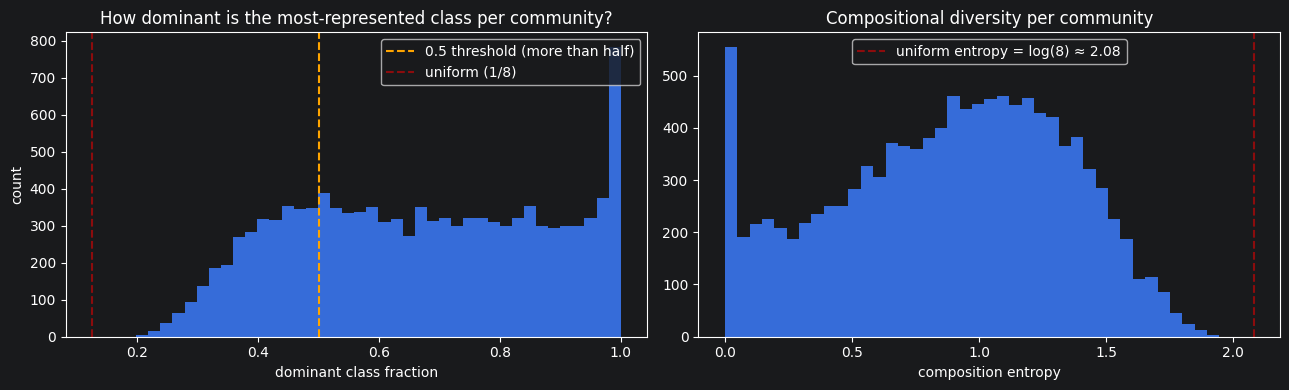

In [16]:
# How "dominant" is the most-represented class in each community?
# A pure single-class community has max_frac = 1.0.
# A perfectly mixed community has max_frac = 1/8 = 0.125.

frac_cols = [f"frac_class_{k}" for k in range(8)]
core["dominant_class"] = core[frac_cols].values.argmax(axis=1)
core["dominant_frac"] = core[frac_cols].values.max(axis=1)
core["composition_entropy"] = -np.sum(
    core[frac_cols].values * np.log(core[frac_cols].values + 1e-12), axis=1
)

print("Distribution of 'dominant class fraction' across communities:")
print(core["dominant_frac"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(3))
print()

# Communities per dominant class
print("Dominant class counts (which classes dominate the most communities?):")
print(core["dominant_class"].value_counts().sort_index())
print()

# Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(core["dominant_frac"], bins=40)
axes[0].axvline(0.5, color="orange", linestyle="--", label="0.5 threshold (more than half)")
axes[0].axvline(1/8, color="red", linestyle="--", alpha=0.5, label="uniform (1/8)")
axes[0].set_xlabel("dominant class fraction")
axes[0].set_ylabel("count")
axes[0].set_title("How dominant is the most-represented class per community?")
axes[0].legend()

axes[1].hist(core["composition_entropy"], bins=40)
axes[1].axvline(np.log(8), color="red", linestyle="--", alpha=0.5,
                label=f"uniform entropy = log(8) ≈ {np.log(8):.2f}")
axes[1].set_xlabel("composition entropy")
axes[1].set_title("Compositional diversity per community")
axes[1].legend()
plt.tight_layout()
plt.show()

## 3.1 What are the pure communities? Are they real or just small?

The spike at `dominant_frac = 1.0` could be a statistical artifact of small community sizes, or it could represent genuine single-cell-type tissue blocks. We disambiguate by looking at the size distribution of "pure" communities vs the rest.

pure communities (dominant_frac ≥ 0.95): 1,334
  of those, n_cells ≥ 100:               818
  of those, n_cells ≥ 500:               208
  of those, n_cells ≥ 1000:              76

mixed communities: 10,162 (median size 388)
  largest mixed community: 5,189 cells


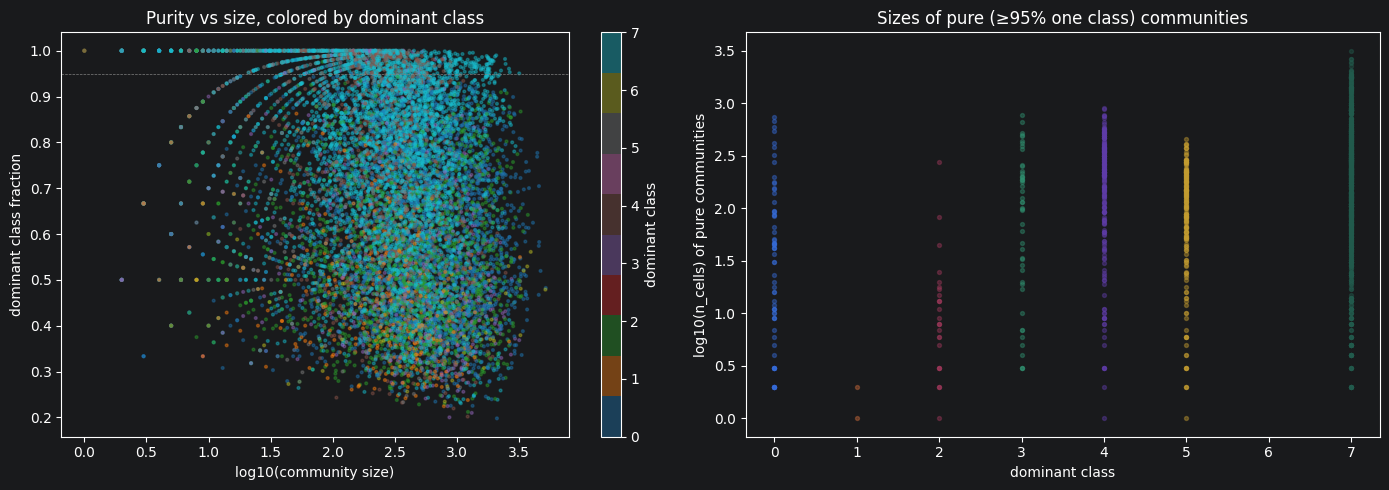

In [17]:
# Pure vs mixed: how does community size relate to compositional purity?

pure = core[core.dominant_frac >= 0.95]
mixed = core[core.dominant_frac < 0.95]
print(f"pure communities (dominant_frac ≥ 0.95): {len(pure):,}")
print(f"  of those, n_cells ≥ 100:               {(pure.n_cells >= 100).sum():,}")
print(f"  of those, n_cells ≥ 500:               {(pure.n_cells >= 500).sum():,}")
print(f"  of those, n_cells ≥ 1000:              {(pure.n_cells >= 1000).sum():,}")
print(f"\nmixed communities: {len(mixed):,} (median size {int(mixed.n_cells.median())})")
print(f"  largest mixed community: {mixed.n_cells.max():,} cells")

# Plot: dominant_frac vs log10(size), colored by dominant class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sc = ax.scatter(np.log10(core.n_cells), core.dominant_frac,
                c=core.dominant_class, cmap="tab10", s=4, alpha=0.4)
ax.set_xlabel("log10(community size)")
ax.set_ylabel("dominant class fraction")
ax.set_title("Purity vs size, colored by dominant class")
ax.axhline(0.95, color="gray", linestyle="--", linewidth=0.5)
plt.colorbar(sc, ax=ax, label="dominant class")

# By dominant class: what's the size distribution of pure communities?
ax = axes[1]
for c in range(8):
    sizes_pure_c = pure[pure.dominant_class == c].n_cells
    if len(sizes_pure_c) > 0:
        ax.scatter([c] * len(sizes_pure_c), np.log10(sizes_pure_c),
                   s=8, alpha=0.4)
ax.set_xlabel("dominant class")
ax.set_ylabel("log10(n_cells) of pure communities")
ax.set_title("Sizes of pure (≥95% one class) communities")
ax.set_xticks(range(8))

plt.tight_layout()
plt.show()

In [18]:
# Class-by-class: how often does each class dominate, and at what size?
print(f"{'class':>6s} {'#dom':>8s} {'#dom_ge_500':>14s} {'median_size':>14s} {'mean_dominant_frac':>20s}")
print("-" * 72)
for c in range(8):
    sub = core[core.dominant_class == c]
    sub_500 = sub[sub.n_cells >= 500]
    print(f"{c:>6d} {len(sub):>8d} {len(sub_500):>14d} "
          f"{int(sub.n_cells.median()) if len(sub) else 0:>14d} "
          f"{sub.dominant_frac.mean() if len(sub) else 0:>20.3f}")

 class     #dom    #dom_ge_500    median_size   mean_dominant_frac
------------------------------------------------------------------------
     0     2531           1287            519                0.621
     1      394             96            284                0.471
     2     1711            733            395                0.559
     3      526            220            364                0.574
     4     1191            297            299                0.695
     5      536             71            172                0.765
     6       57             38           1010                0.410
     7     4550           1555            343                0.746


## 4. Cross-sample alignment: finding recurrent niche types

We cluster the per-sample communities by their cell-type composition vectors to identify "niche types" that recur across samples and patients.

**Approach:** filter to communities with ≥100 cells (excluding anomalies), compute L1 pairwise distances between their 8-d composition vectors, run hierarchical clustering with **average linkage**, and cut the dendrogram at a chosen K.

**Why L1 + average linkage:** L1 distance on compositions has a clean interpretation (total compositional divergence, bounded by 2). Average linkage works directly on any precomputed distance matrix, unlike Ward which requires Euclidean.

**Filter rationale:** ≥100 cells ensures the composition vector is statistically meaningful (~3 expected cells of the rarest class if community matched cohort average); 9,457 of 11,496 non-anomaly communities pass this filter.

In [19]:
# §4.1: Prepare data

# Filter
align_df = core[core.n_cells >= 100].reset_index(drop=True).copy()
print(f"communities for alignment: {len(align_df):,}")
print(f"  (of {len(core):,} non-anomaly communities; threshold n_cells ≥ 100)")

# 8-d composition matrix
frac_cols = [f"frac_class_{k}" for k in range(8)]
X = align_df[frac_cols].values
print(f"\ncomposition matrix: shape={X.shape}, sums to 1 per row: "
      f"{np.allclose(X.sum(axis=1), 1.0)}")

communities for alignment: 9,457
  (of 11,496 non-anomaly communities; threshold n_cells ≥ 100)

composition matrix: shape=(9457, 8), sums to 1 per row: True


In [20]:
# §4.2: Pairwise L1 distances + hierarchical clustering

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

print(f"computing pairwise L1 distances on {len(X)} compositions...")
t0 = time.time()
# pdist returns the condensed distance vector (upper triangle), shape (N*(N-1)/2,)
D_cond = pdist(X, metric="cityblock")    # cityblock = L1 = Manhattan
print(f"  done in {time.time() - t0:.1f}s, "
      f"distances shape: {D_cond.shape}, "
      f"memory: {D_cond.nbytes / 1e6:.0f} MB")
print(f"  L1 distance range: [{D_cond.min():.3f}, {D_cond.max():.3f}]  "
      f"(theoretical max: 2.0)")
print(f"  median pairwise distance: {np.median(D_cond):.3f}")

print("\nrunning average linkage...")
t0 = time.time()
Z = linkage(D_cond, method="average")
print(f"  done in {time.time() - t0:.1f}s")

computing pairwise L1 distances on 9457 compositions...
  done in 0.3s, distances shape: (44712696,), memory: 358 MB
  L1 distance range: [0.000, 2.000]  (theoretical max: 2.0)
  median pairwise distance: 1.427

running average linkage...
  done in 1.3s


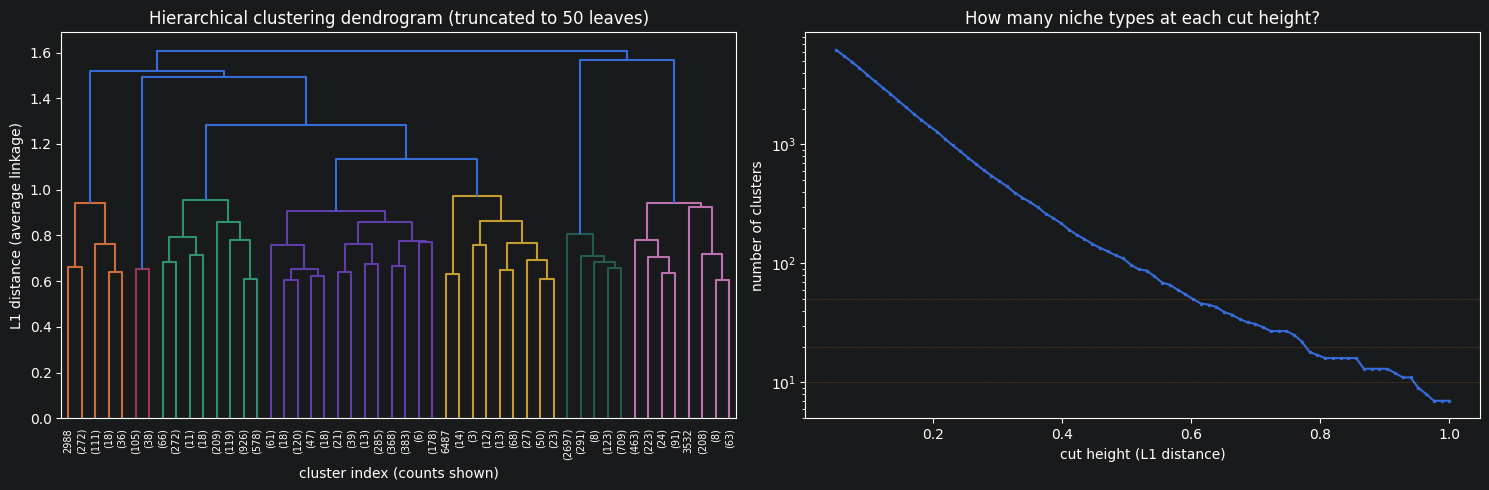

Candidate K values:
  K=5: cluster sizes (sorted desc, top 10): [np.int64(3967), np.int64(3828), np.int64(1081), np.int64(438), np.int64(143)], smallest: 143
  K=10: cluster sizes (sorted desc, top 10): [np.int64(3828), np.int64(1832), np.int64(1557), np.int64(801), np.int64(438), np.int64(367), np.int64(280), np.int64(196), np.int64(143), np.int64(15)], smallest: 15
  K=15: cluster sizes (sorted desc, top 10): [np.int64(3828), np.int64(1832), np.int64(935), np.int64(801), np.int64(367), np.int64(358), np.int64(279), np.int64(273), np.int64(264), np.int64(181)], smallest: 1
  K=20: cluster sizes (sorted desc, top 10): [np.int64(2697), np.int64(1504), np.int64(1131), np.int64(935), np.int64(463), np.int64(358), np.int64(338), np.int64(338), np.int64(279), np.int64(273)], smallest: 1
  K=30: cluster sizes (sorted desc, top 10): [np.int64(2697), np.int64(1504), np.int64(840), np.int64(751), np.int64(463), np.int64(338), np.int64(338), np.int64(298), np.int64(291), np.int64(273)], smallest

In [21]:
# §4.2 cont.: dendrogram + how does cluster count vary with cut height?

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Truncated dendrogram (no point showing 9,500 leaves)
ax = axes[0]
dendrogram(Z, truncate_mode="lastp", p=50, ax=ax,
           leaf_rotation=90, leaf_font_size=7,
           show_leaf_counts=True)
ax.set_xlabel("cluster index (counts shown)")
ax.set_ylabel("L1 distance (average linkage)")
ax.set_title("Hierarchical clustering dendrogram (truncated to 50 leaves)")

# Number of clusters as a function of cut height
ax = axes[1]
heights = np.linspace(0.05, 1.0, 80)
n_clusters_at_h = [len(np.unique(fcluster(Z, t=h, criterion="distance"))) for h in heights]
ax.plot(heights, n_clusters_at_h, marker=".", markersize=3)
ax.set_xlabel("cut height (L1 distance)")
ax.set_ylabel("number of clusters")
ax.set_yscale("log")
ax.set_title("How many niche types at each cut height?")
ax.axhline(10, color="orange", alpha=0.5, linewidth=0.5, linestyle=":")
ax.axhline(20, color="orange", alpha=0.5, linewidth=0.5, linestyle=":")
ax.axhline(50, color="orange", alpha=0.5, linewidth=0.5, linestyle=":")

plt.tight_layout()
plt.show()

# Print a few candidate K values
print("Candidate K values:")
for K in [5, 10, 15, 20, 30, 50]:
    clusters = fcluster(Z, t=K, criterion="maxclust")
    sizes = np.bincount(clusters)[1:]   # cluster IDs are 1-indexed
    print(f"  K={K}: cluster sizes (sorted desc, top 10): "
          f"{sorted(sizes, reverse=True)[:10]}, "
          f"smallest: {sizes.min()}")

## 4.2.1 Revising the linkage method

Average linkage produced singleton clusters at K ≥ 15, which signals a chaining problem typical of average linkage on continuous-composition data. We compare two alternatives and pick whichever produces cleaner cluster sizes while preserving the meaningful niche structure visible in the dendrogram.

**Option A** (current): L1 distance + average linkage. Singletons appear at K=15+.
**Option B**: L1 distance + complete linkage. Avoids chaining but may over-segment.
**Option C**: Euclidean distance + Ward linkage. Standard for content-based clustering; slight theoretical mismatch on the simplex but well-behaved in practice.

In [22]:
# Compare complete-linkage L1 and Ward-Euclidean at the same K values

from scipy.spatial.distance import squareform

print("Option B: L1 + complete linkage")
Z_complete = linkage(D_cond, method="complete")
for K in [10, 15, 20, 25, 30]:
    clusters = fcluster(Z_complete, t=K, criterion="maxclust")
    sizes = sorted(np.bincount(clusters)[1:], reverse=True)
    print(f"  K={K}: sizes (top 6): {sizes[:6]}, smallest: {sizes[-1]}")

print("\nOption C: Euclidean + Ward")
# Ward requires the linkage to compute from raw data, not precomputed distances
Z_ward = linkage(X, method="ward")
for K in [10, 15, 20, 25, 30]:
    clusters = fcluster(Z_ward, t=K, criterion="maxclust")
    sizes = sorted(np.bincount(clusters)[1:], reverse=True)
    print(f"  K={K}: sizes (top 6): {sizes[:6]}, smallest: {sizes[-1]}")

Option B: L1 + complete linkage
  K=10: sizes (top 6): [np.int64(3484), np.int64(2135), np.int64(1068), np.int64(985), np.int64(435), np.int64(395)], smallest: 144
  K=15: sizes (top 6): [np.int64(3484), np.int64(1422), np.int64(1068), np.int64(806), np.int64(550), np.int64(395)], smallest: 47
  K=20: sizes (top 6): [np.int64(3484), np.int64(1271), np.int64(671), np.int64(569), np.int64(550), np.int64(320)], smallest: 47
  K=25: sizes (top 6): [np.int64(2502), np.int64(1271), np.int64(982), np.int64(671), np.int64(569), np.int64(550)], smallest: 22
  K=30: sizes (top 6): [np.int64(2502), np.int64(1271), np.int64(982), np.int64(671), np.int64(569), np.int64(451)], smallest: 22

Option C: Euclidean + Ward
  K=10: sizes (top 6): [np.int64(2087), np.int64(1935), np.int64(1141), np.int64(1051), np.int64(856), np.int64(678)], smallest: 169
  K=15: sizes (top 6): [np.int64(2087), np.int64(1082), np.int64(856), np.int64(853), np.int64(777), np.int64(678)], smallest: 169
  K=20: sizes (top 6): 

In [23]:
# Commit to Ward + Euclidean at K=20
K = 20

Z_final = linkage(X, method="ward")        # already computed in Cell 31, redo cleanly
niche_id_per_community = fcluster(Z_final, t=K, criterion="maxclust")  # 1-indexed
# remap to 0-indexed so we can use as array indices
niche_id_per_community = niche_id_per_community - 1

align_df["niche_id"] = niche_id_per_community
print(f"assigned niche IDs to {len(align_df)} communities, K={K}")
print(f"\nniche sizes (descending):")
sizes = align_df.groupby("niche_id").size().sort_values(ascending=False)
print(sizes.to_string())

assigned niche IDs to 9457 communities, K=20

niche sizes (descending):
niche_id
1     1105
0      982
16     856
2      853
4      705
19     538
7      487
13     462
5      425
12     386
3      377
9      362
10     300
11     293
17     274
18     239
14     228
15     225
6      191
8      169


In [24]:
# §4.3: niche-type centroids — what do these niches "look like"?

niche_centroids = align_df.groupby("niche_id")[frac_cols].mean()
niche_centroids["dominant_class"] = niche_centroids[frac_cols].values.argmax(axis=1)
niche_centroids["dominant_frac"] = niche_centroids[frac_cols].values.max(axis=1)
niche_centroids["composition_entropy"] = -np.sum(
    niche_centroids[frac_cols].values * np.log(niche_centroids[frac_cols].values + 1e-12),
    axis=1
)
niche_centroids["n_communities"] = align_df.groupby("niche_id").size()
niche_centroids["n_total_cells"] = align_df.groupby("niche_id")["n_cells"].sum()
niche_centroids["n_samples"] = align_df.groupby("niche_id")["sample_id"].nunique()
niche_centroids["n_patients"] = align_df.groupby("niche_id")["patient"].nunique()

# Order by population
niche_centroids = niche_centroids.sort_values("n_communities", ascending=False)
print("Niche-type centroids (sorted by population):\n")
display_cols = (frac_cols +
                ["dominant_class", "dominant_frac", "composition_entropy",
                 "n_communities", "n_total_cells", "n_samples", "n_patients"])
print(niche_centroids[display_cols].round(3).to_string())

Niche-type centroids (sorted by population):

          frac_class_0  frac_class_1  frac_class_2  frac_class_3  frac_class_4  frac_class_5  frac_class_6  frac_class_7  dominant_class  dominant_frac  composition_entropy  n_communities  n_total_cells  n_samples  n_patients
niche_id                                                                                                                                                                                                                         
1                0.005         0.021         0.095         0.036         0.024         0.001         0.002         0.816               7          0.816                0.726           1105         585026         67          48
0                0.001         0.003         0.026         0.009         0.009         0.000         0.000         0.951               7          0.951                0.255            982         529147         57          45
16               0.789         0.078         0.073

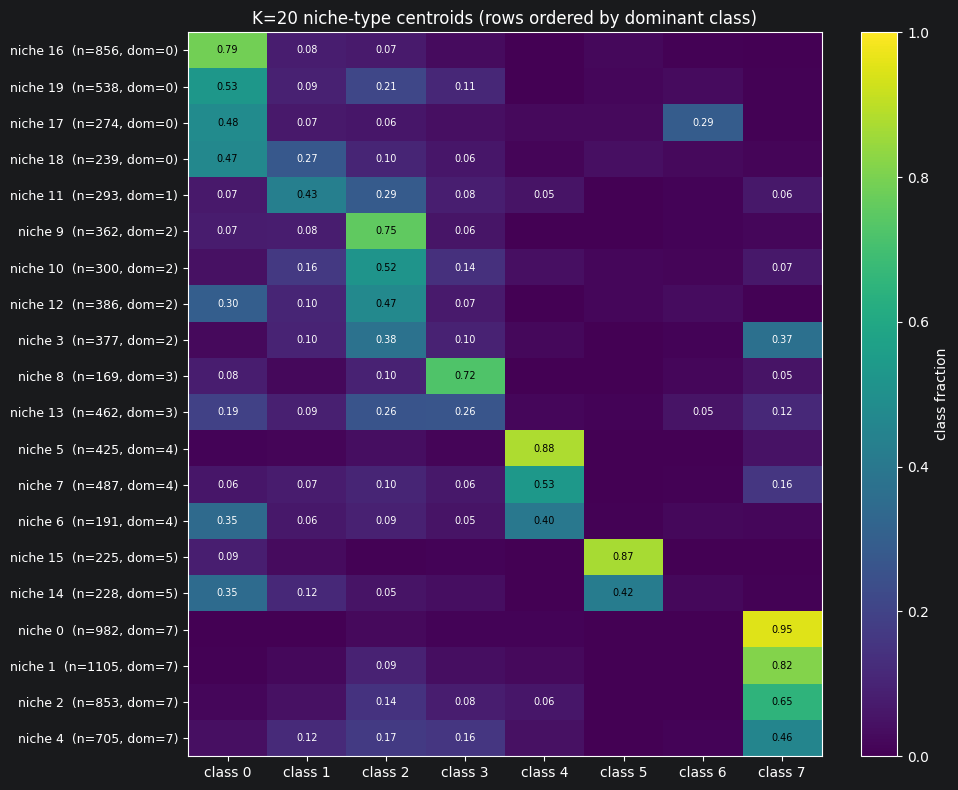

In [25]:
# Visualize the centroid compositions as a heatmap

fig, ax = plt.subplots(figsize=(10, 8))
# Order rows by dominant class then dominant fraction (so similar niches sit together)
ordered_idx = niche_centroids.sort_values(
    ["dominant_class", "dominant_frac"], ascending=[True, False]
).index
mat = niche_centroids.loc[ordered_idx, frac_cols].values
im = ax.imshow(mat, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(8))
ax.set_xticklabels([f"class {k}" for k in range(8)])
ax.set_yticks(range(K))
ax.set_yticklabels(
    [f"niche {i}  (n={niche_centroids.loc[i,'n_communities']}, "
     f"dom={niche_centroids.loc[i,'dominant_class']})" for i in ordered_idx],
    fontsize=9,
)
plt.colorbar(im, ax=ax, label="class fraction")
ax.set_title(f"K={K} niche-type centroids (rows ordered by dominant class)")

# annotate
for i, niche in enumerate(ordered_idx):
    for j in range(8):
        v = mat[i, j]
        if v > 0.05:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v < 0.4 else "black", fontsize=7)
plt.tight_layout()
plt.show()

## 4.4 Niche recurrence across patients and folds

For each of the 20 niche types, we count:

- Total **patients** in which this niche appears (anywhere across their 2 samples).
- Patients **per fold** (train / val / test).

A niche found in >80% of patients is a **robust recurrent niche** — strong evidence that the niche type is a feature of the biology, not patient-specific. A niche in <30% of patients is **patient-specific** — possibly disease-state or sub-population specific.

In [26]:
# Patient-level recurrence per niche

# Add fold info to align_df (using patient_fold from §0)
align_df["fold"] = align_df["patient"].map(patient_fold)

# For each niche, count distinct patients in each fold
recurrence = align_df.groupby("niche_id").apply(
    lambda g: pd.Series({
        "n_patients_total":   g["patient"].nunique(),
        "n_patients_train":   g[g.fold == "train"]["patient"].nunique(),
        "n_patients_val":     g[g.fold == "val"]["patient"].nunique(),
        "n_patients_test":    g[g.fold == "test"]["patient"].nunique(),
        "n_communities":      len(g),
    }),
    include_groups=False,
).astype(int)

# Add patient-coverage fractions
recurrence["frac_patients"]      = recurrence["n_patients_total"] / 56
recurrence["frac_train"]         = recurrence["n_patients_train"] / 40
recurrence["frac_val"]           = recurrence["n_patients_val"] / 8
recurrence["frac_test"]          = recurrence["n_patients_test"] / 8
recurrence["dominant_class"]     = niche_centroids["dominant_class"]

# Order by total patient coverage
recurrence = recurrence.sort_values("n_patients_total", ascending=False)
print("Niche recurrence (sorted by patient coverage):\n")
print(recurrence.round(3).to_string())

Niche recurrence (sorted by patient coverage):

          n_patients_total  n_patients_train  n_patients_val  n_patients_test  n_communities  frac_patients  frac_train  frac_val  frac_test  dominant_class
niche_id                                                                                                                                                    
4                       53                37               8                8            705          0.946       0.925     1.000      1.000               7
2                       52                36               8                8            853          0.929       0.900     1.000      1.000               7
13                      48                33               8                7            462          0.857       0.825     1.000      0.875               3
1                       48                34               7                7           1105          0.857       0.850     0.875      0.875               7
0         

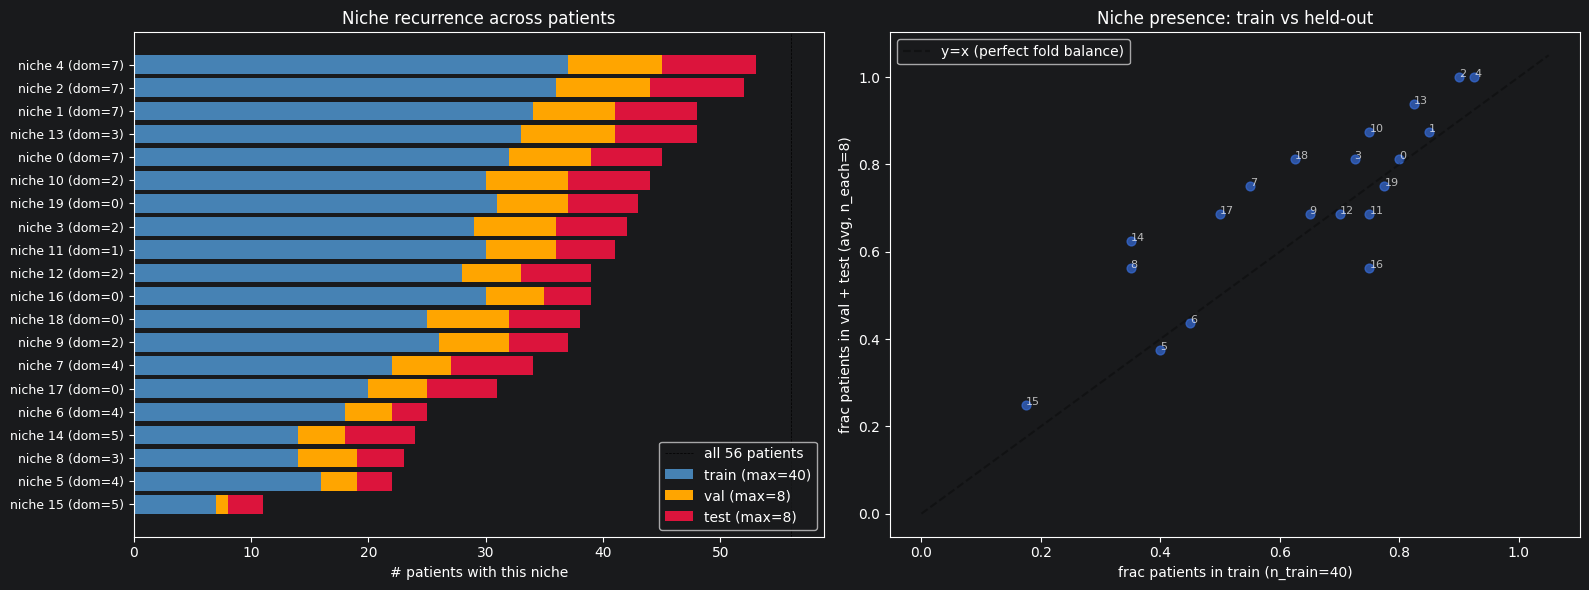

In [27]:
# Visualize recurrence

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Patient coverage per niche, with fold breakdown
ax = axes[0]
ordered = recurrence.sort_values("n_patients_total", ascending=True)
y = np.arange(len(ordered))
ax.barh(y, ordered["n_patients_train"], color="steelblue", label="train (max=40)")
ax.barh(y, ordered["n_patients_val"],   left=ordered["n_patients_train"],
        color="orange", label="val (max=8)")
ax.barh(y, ordered["n_patients_test"],  left=ordered["n_patients_train"] + ordered["n_patients_val"],
        color="crimson", label="test (max=8)")
ax.set_yticks(y)
ax.set_yticklabels(
    [f"niche {i} (dom={recurrence.loc[i,'dominant_class']})" for i in ordered.index],
    fontsize=9,
)
ax.set_xlabel("# patients with this niche")
ax.axvline(56, color="black", linewidth=0.5, linestyle="--", label="all 56 patients")
ax.set_title("Niche recurrence across patients")
ax.legend(loc="lower right")

# Fold-coverage scatter: train_frac vs (val + test) frac
ax = axes[1]
ax.scatter(recurrence["frac_train"], (recurrence["frac_val"] + recurrence["frac_test"]) / 2,
           s=40, alpha=0.7)
for nid, row in recurrence.iterrows():
    ax.annotate(str(nid), (row["frac_train"], (row["frac_val"] + row["frac_test"]) / 2),
                fontsize=8, alpha=0.7)
lim = [0, 1.05]
ax.plot(lim, lim, "k--", alpha=0.3, label="y=x (perfect fold balance)")
ax.set_xlabel("frac patients in train (n_train=40)")
ax.set_ylabel("frac patients in val + test (avg, n_each=8)")
ax.set_title("Niche presence: train vs held-out")
ax.legend()

plt.tight_layout()
plt.show()

## 4.5 Persist niche assignments and centroid table

Save the niche assignments and centroid composition table for use in §5 (spatial visualization) and Part 5 (multi-layer integration). We also persist the per-(patient, niche) cell-count matrix as a compact summary of "which niches each patient has."

In [28]:
# Save the niche-id per community (in align_df)
niche_assignments_path = comm_cache / "niche_assignments.parquet"
# Keep just what's needed downstream
niche_assignments_df = align_df[[
    "sample_id", "community_id", "patient", "fold", "n_cells",
    "centroid_x", "centroid_y", "niche_id"
]].copy()
niche_assignments_df.to_parquet(niche_assignments_path)
print(f"saved per-community niche assignments to {niche_assignments_path}")
print(f"  shape: {niche_assignments_df.shape}")

# Save the centroid table
centroids_path = comm_cache / "niche_centroids.parquet"
niche_centroids.to_parquet(centroids_path)
print(f"saved niche centroids to {centroids_path}")
print(f"  shape: {niche_centroids.shape}")

# Per-(patient, niche) cell-count matrix
patient_niche_cells = align_df.groupby(["patient", "niche_id"])["n_cells"].sum().unstack(fill_value=0)
patient_niche_path = comm_cache / "patient_niche_matrix.parquet"
patient_niche_cells.to_parquet(patient_niche_path)
print(f"saved patient × niche cell-count matrix to {patient_niche_path}")
print(f"  shape: {patient_niche_cells.shape}  (n_patients × K niches)")

saved per-community niche assignments to ../cache/communities/niche_assignments.parquet
  shape: (9457, 8)
saved niche centroids to ../cache/communities/niche_centroids.parquet
  shape: (20, 15)
saved patient × niche cell-count matrix to ../cache/communities/patient_niche_matrix.parquet
  shape: (56, 20)  (n_patients × K niches)


## 4.6 Niche-tier interpretation

The 20 niche types arrange into a graded continuum of patient-recurrence:

- **Universal niches** (≥80% of patients): niches 1, 2, 4 (class 7 family) and niche 13 (heterogeneous). These represent the structural backbone of the tissue — present in nearly every section.
- **Common niches** (60–80% of patients): niches 0, 3, 10, 11, 12, 16, 17, 18, 19 — class 0, 1, 2 dominated mixed-composition niches that recur frequently.
- **Selective niches** (40–60% of patients): niches 6, 7, 8, 14, 17 — present in roughly half the cohort.
- **Rare niches** (<40% of patients): niche 5 (pure class 4), niche 15 (pure class 5). These appear in only 11–22 patients — likely specialized tissue features.

**Notable patterns:**

- Class 7 (the most abundant class) is the dominant component of every "universal" niche — class 7 is structurally central to all sampled tissue.
- Class 6 never dominates a niche but appears as a **substantial secondary component (29%) in niche 17** (which is class-0-dominant). Combined with §3 findings (only 57 communities had class 6 as plurality, and those were large+mixed), this confirms class 6's role as a *minority component within class-0-rich regions*, never forming its own tissue territory.
- The two purest minority-class niches (15 = pure class 5; 5 = pure class 4) are the rarest, suggesting these classes form specialized enclaves that not all patients share. Class 5 in particular forms a tight, recognizable niche when present.
- Fold balance is good overall — niches sit near the y=x diagonal in the train-vs-heldout plot. Two niches (16, 15) show mild fold imbalance, expected since we stratified the split on cell-type composition rather than niche structure.

## 5. Spatial visualization of niches

To confirm visually that the niches identified by composition-based alignment correspond to coherent tissue regions, we plot the spatial layout of several samples colored by niche ID. Niche colors are consistent across samples (niche 0 is always the same color), so we can see directly whether the same niche appears in similar spatial contexts across patients.

**Sample selection:** four samples chosen to span:
- The cohort's main niche diversity (samples with many niches present).
- At least one sample containing niche 15 (the rare class-5 enclave).
- A mix of patients and folds.

In [29]:
# Build a (n_cells,) array of niche assignments for ALL cells in the cohort,
# so we can quickly index any sample. Cells without niche assignment get -1.
# Map: (sample_id, community_id) -> niche_id from niche_assignments_df.

niche_map = niche_assignments_df.set_index(["sample_id", "community_id"])["niche_id"]
print(f"niche_map has {len(niche_map):,} (sample, community) entries")

niche_per_cell = np.full(G.n_cells, -1, dtype=np.int16)
for s in sorted(int(x) for x in np.unique(G.sample)):
    s_mask = G.sample == s
    s_idxs = np.where(s_mask)[0]
    s_labels = global_labels[s_idxs]  # community labels per cell, -1 = non-giant
    if s not in niche_map.index.get_level_values(0):
        continue  # sample had no qualifying communities (e.g., anomaly)
    s_map = niche_map.loc[s]  # community_id -> niche_id for THIS sample
    for cid, nid in s_map.items():
        cell_mask_in_sample = s_labels == cid
        niche_per_cell[s_idxs[cell_mask_in_sample]] = nid

print(f"\ncells with a niche assignment: {(niche_per_cell >= 0).sum():,} "
      f"({100*(niche_per_cell >= 0).mean():.1f}%)")
print(f"unique niches present: {sorted(np.unique(niche_per_cell[niche_per_cell >= 0]).tolist())}")

# persist for downstream parts
niche_per_cell_path = comm_cache / "niche_per_cell.npy"
np.save(niche_per_cell_path, niche_per_cell)
print(f"saved per-cell niche assignments to {niche_per_cell_path}")

niche_map has 9,457 (sample, community) entries

cells with a niche assignment: 6,209,683 (77.0%)
unique niches present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
saved per-cell niche assignments to ../cache/communities/niche_per_cell.npy


In [30]:
# Pick samples for visualization
# Criteria: each chosen sample should have many distinct niches (diverse tissue),
# include patients from different folds, and at least one sample should have niche 15.

niches_per_sample = (
    niche_assignments_df.groupby("sample_id")["niche_id"].nunique()
    .sort_values(ascending=False)
)
print("Samples with most distinct niches present:")
print(niches_per_sample.head(15))
print()

# Which samples have niche 15?
samples_with_niche15 = niche_assignments_df.query("niche_id == 15")["sample_id"].unique()
print(f"Samples containing niche 15 (rare class-5 enclave): {len(samples_with_niche15)} samples")
print(f"  first few: {sorted(samples_with_niche15)[:10]}")

# Pick: top-niche-diversity sample, + a sample with niche 15, + 2 more from different folds
diverse_samples = niches_per_sample.head(5).index.tolist()
# Find a sample with niche 15 from a different patient than the diverse ones already chosen
diverse_patients = set(int(G.patient[G.sample == s][0]) for s in diverse_samples)
n15_candidate = next(
    (int(s) for s in sorted(samples_with_niche15)
     if int(G.patient[G.sample == s][0]) not in diverse_patients),
    int(samples_with_niche15[0])
)

VIZ_SAMPLES = diverse_samples[:3] + [n15_candidate]
# Deduplicate while preserving order
seen = set(); VIZ_SAMPLES = [s for s in VIZ_SAMPLES if not (s in seen or seen.add(s))]
print(f"\nselected: {VIZ_SAMPLES}")
for s in VIZ_SAMPLES:
    p = int(G.patient[G.sample == s][0])
    n_niches_here = int(niches_per_sample.get(s, 0))
    has_15 = bool((niche_per_cell[G.sample == s] == 15).any())
    print(f"  sample {s}: patient {p}, fold {patient_fold[p]}, "
          f"{n_niches_here} distinct niches, niche 15 present: {has_15}")

Samples with most distinct niches present:
sample_id
1     16
25    14
93    14
99    14
86    14
45    13
83    13
85    13
78    13
33    13
3     13
37    13
13    12
49    12
5     12
Name: niche_id, dtype: int64

Samples containing niche 15 (rare class-5 enclave): 11 samples
  first few: [np.int64(3), np.int64(5), np.int64(15), np.int64(21), np.int64(25), np.int64(29), np.int64(37), np.int64(69), np.int64(91), np.int64(97)]

selected: [1, 25, 93, 3]
  sample 1: patient 37, fold train, 16 distinct niches, niche 15 present: False
  sample 25: patient 28, fold test, 14 distinct niches, niche 15 present: True
  sample 93: patient 44, fold train, 14 distinct niches, niche 15 present: False
  sample 3: patient 19, fold train, 13 distinct niches, niche 15 present: True


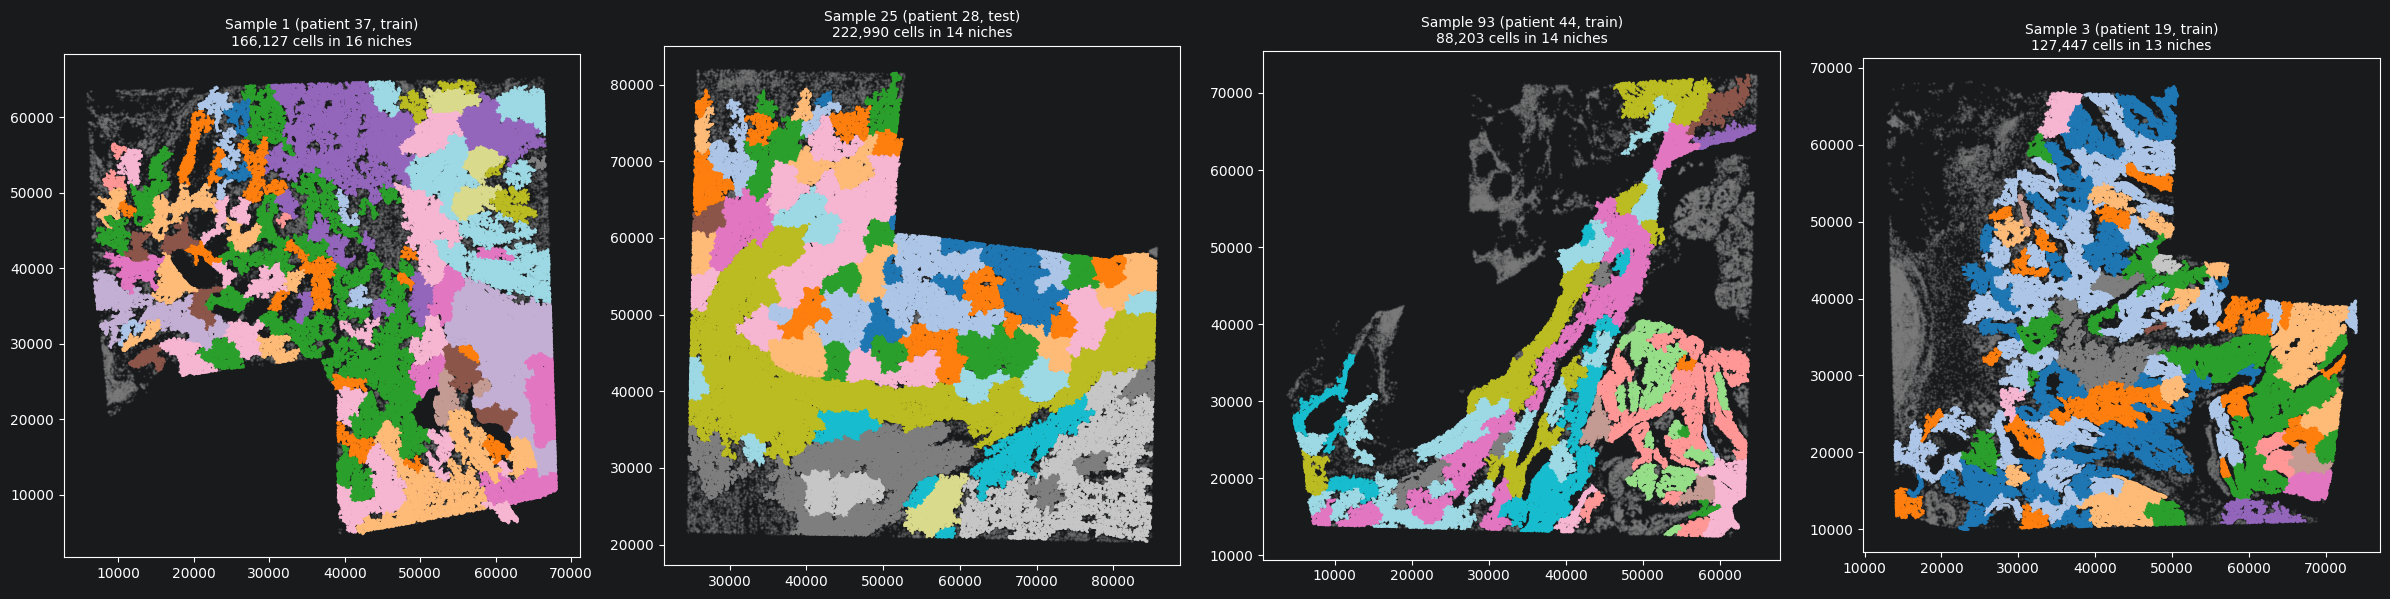

In [31]:
# Combined-color view of niches across the chosen samples

n = len(VIZ_SAMPLES)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
if n == 1:
    axes = [axes]

cmap20 = plt.cm.tab20

for ax, s in zip(axes, VIZ_SAMPLES):
    s_mask = G.sample == s
    pos = G.positions[s_mask]
    niches_here = niche_per_cell[s_mask]
    in_niche = niches_here >= 0

    # Background: cells with no niche assignment
    ax.scatter(pos[~in_niche, 0], pos[~in_niche, 1], s=0.3, c="gray", alpha=0.25)
    # Foreground: niche-colored
    ax.scatter(pos[in_niche, 0], pos[in_niche, 1], s=0.6,
               c=niches_here[in_niche], cmap=cmap20, vmin=0, vmax=19, alpha=0.85)
    p = int(G.patient[s_mask][0])
    ax.set_aspect("equal")
    ax.set_title(f"Sample {s} (patient {p}, {patient_fold[p]})\n"
                 f"{int(in_niche.sum()):,} cells in {int(np.unique(niches_here[in_niche]).size)} niches",
                 fontsize=10)

plt.tight_layout()
plt.show()

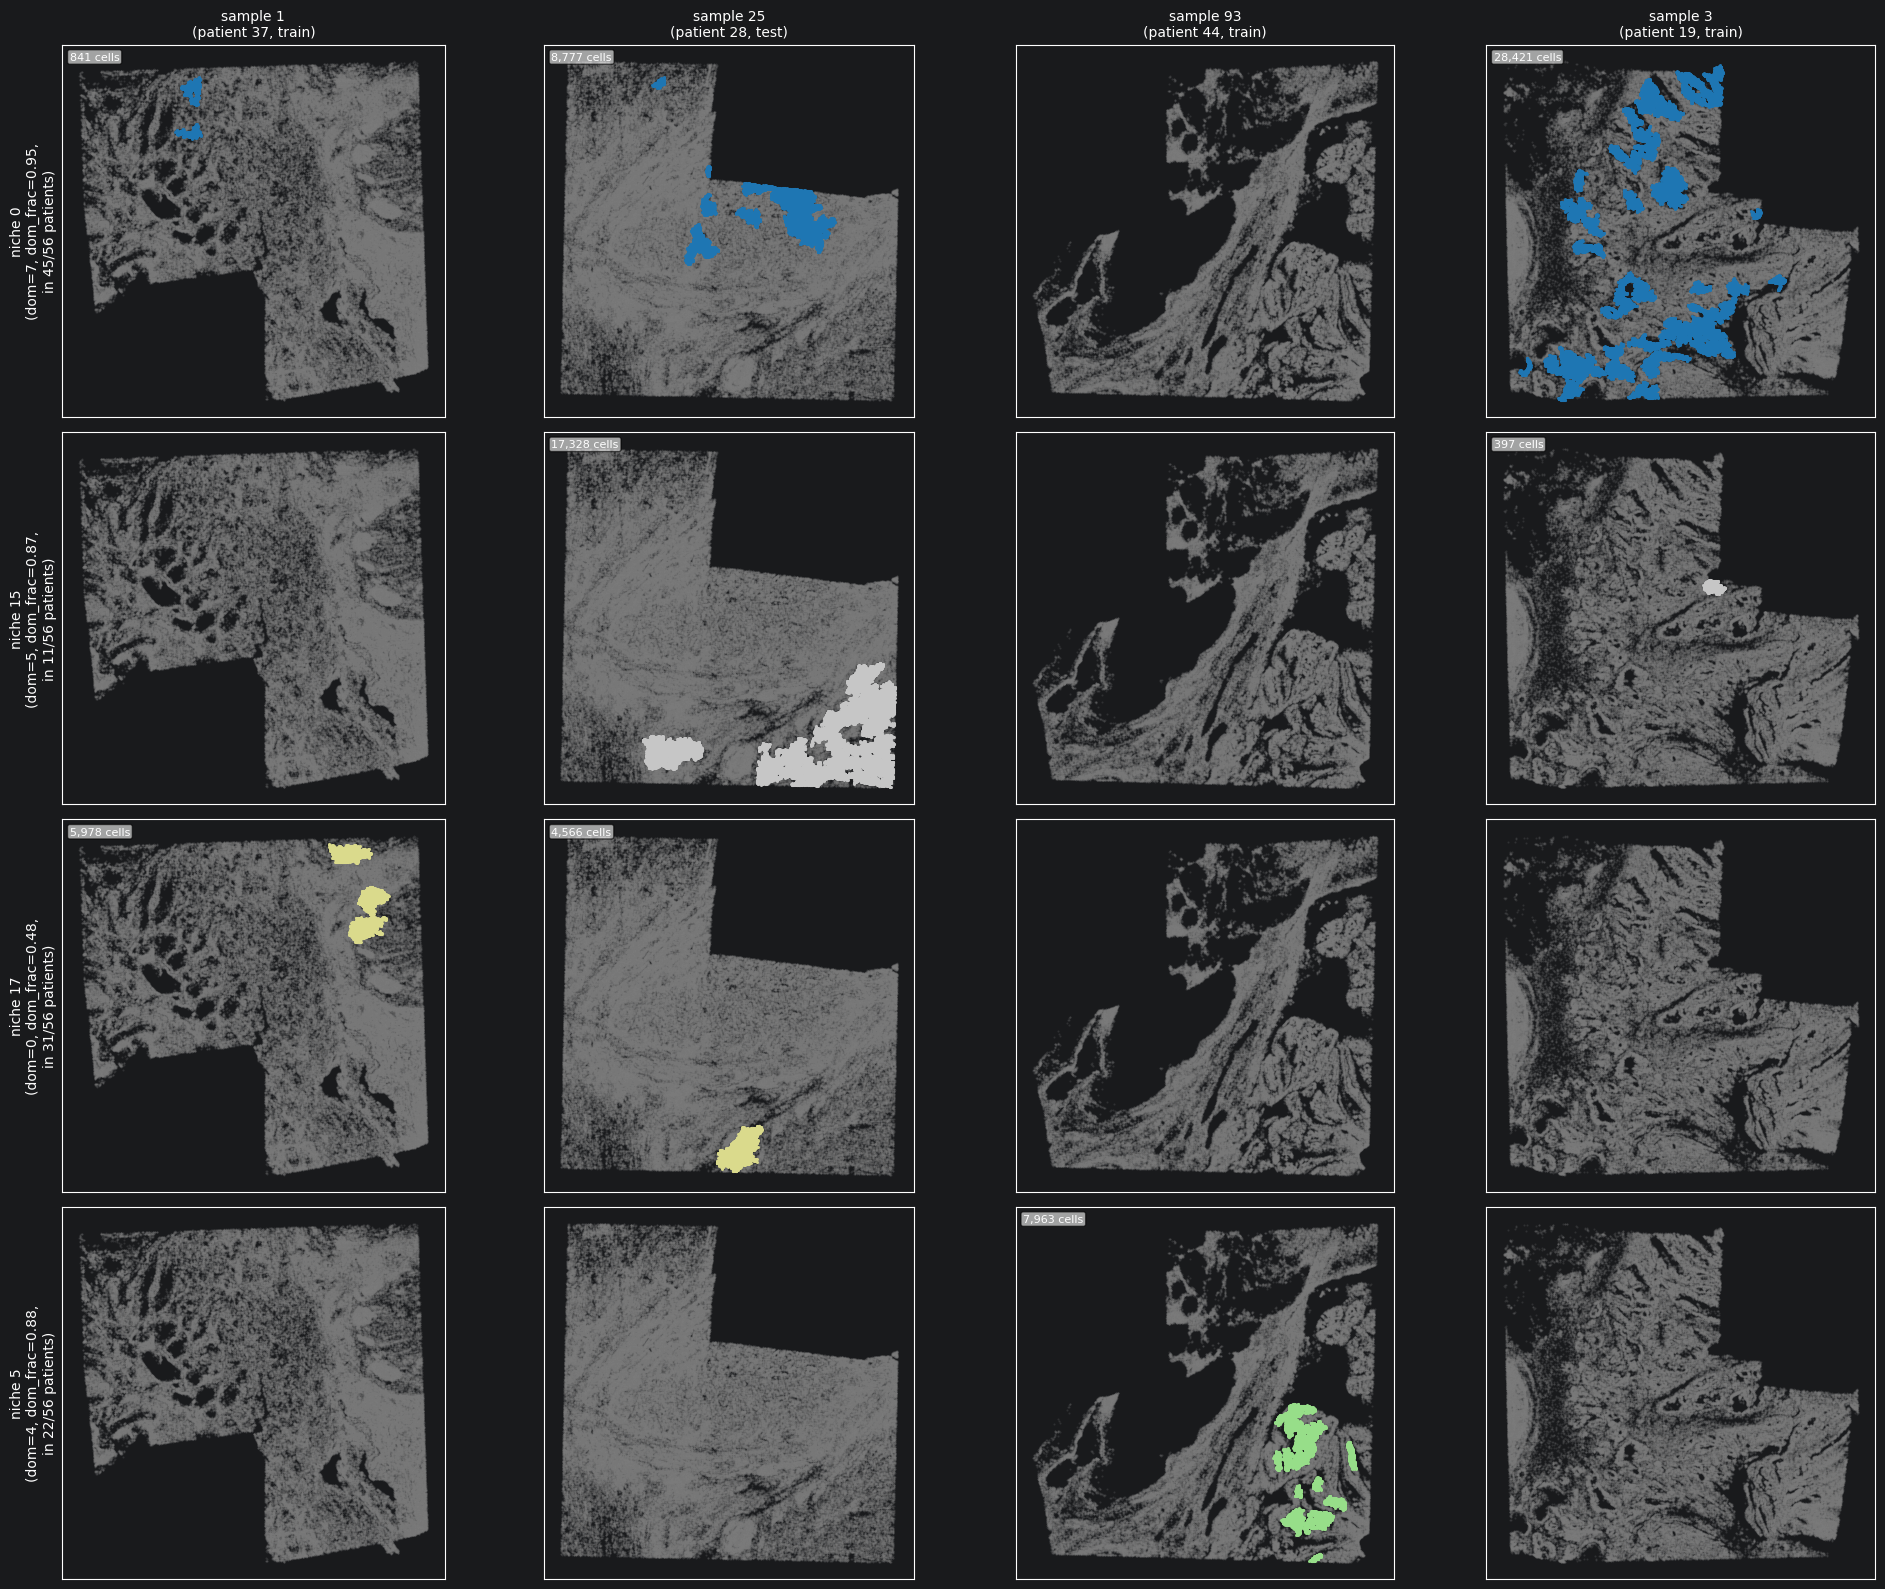

In [32]:
# Per-niche overlay: for a few interesting niches, show where they appear
# across the four samples. Gray background = all other cells.

NICHE_OVERLAY = [0, 15, 17, 5]  # universal class-7, rare class-5, class-6 mediator, rare class-4

fig, axes = plt.subplots(len(NICHE_OVERLAY), len(VIZ_SAMPLES),
                         figsize=(5 * len(VIZ_SAMPLES), 4 * len(NICHE_OVERLAY)),
                         squeeze=False)

for row, nid in enumerate(NICHE_OVERLAY):
    dom = int(niche_centroids.loc[nid, "dominant_class"])
    dom_frac = float(niche_centroids.loc[nid, "dominant_frac"])
    n_pat = int(recurrence.loc[nid, "n_patients_total"])
    color = cmap20(nid / 20)

    for col, s in enumerate(VIZ_SAMPLES):
        ax = axes[row, col]
        s_mask = G.sample == s
        pos = G.positions[s_mask]
        niches_here = niche_per_cell[s_mask]
        is_niche = niches_here == nid

        ax.scatter(pos[~is_niche, 0], pos[~is_niche, 1], s=0.3, c="gray", alpha=0.2)
        if is_niche.any():
            ax.scatter(pos[is_niche, 0], pos[is_niche, 1], s=1.5,
                       c=[color], alpha=0.9)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])

        if col == 0:
            ax.set_ylabel(
                f"niche {nid}\n(dom={dom}, dom_frac={dom_frac:.2f},\n"
                f"in {n_pat}/56 patients)",
                fontsize=10,
            )
        if row == 0:
            p = int(G.patient[s_mask][0])
            ax.set_title(f"sample {s}\n(patient {p}, {patient_fold[p]})", fontsize=10)
        # Annotate count in this sample
        if is_niche.any():
            ax.text(0.02, 0.98, f"{is_niche.sum():,} cells",
                    transform=ax.transAxes, va="top", ha="left", fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

plt.tight_layout()
plt.show()

## 6. Summary of Part 2

### What we found

**The cohort's spatial cell graphs admit reproducible community structure.** Per-sample Leiden (γ=0.5, weighted by `1 - mean_neighbor_radius`, on the giant connected component) produces a median of 76 communities per sample, with sizes scaling smoothly with giant-component size (Spearman ρ = 0.83). At γ=0.5 the largest community in any sample covers only ~3% of cells; communities are spatially coherent, contiguous patches that respect tissue topology.

**Per-community compositions reveal class-specific tissue grouping behaviors.** Across the 11,496 non-anomaly communities, the dominant-class fraction is broadly distributed (median 0.67), with a meaningful population of single-class communities (~1,300 with dominant_frac ≥ 0.95, of which 818 contain ≥100 cells). The 8 classes show very different "grouping" patterns:
- **Class 7** (the most abundant class) dominates the most communities (4,550), forming the structural backbone of much tissue.
- **Class 5** forms small, very pure enclaves (mean dominant fraction 0.77 when it dominates).
- **Class 6** rarely dominates (only 57 communities) and when it does, forms large mixed communities where it is the plurality — the signature of a minority "interfacing" cell type.

**Cross-sample alignment identifies 20 recurrent niche types.** Composition vectors of communities (n_cells ≥ 100) cluster cleanly into K=20 niche types via hierarchical clustering with Ward linkage. The K=20 niches arrange into 8 families, one per dominant class except class 6 (which has no family of its own). Within each family, niches differ by their mixing partners: class 7 forms 4 distinct niches (pure, plus mixtures with classes 2, 3, and a heterogeneous variant).

**Niche recurrence forms a graded continuum across patients.** The 20 niches range from universal (present in ≥80% of patients — niches 1, 2, 4, 13) to rare (present in <40% — niche 5 in 22 patients, niche 15 in 11 patients). Universal niches are predominantly class 7 family — i.e., the structural-backbone tissue. Rare niches are pure class 4 and class 5 enclaves, suggesting specialized tissue features not shared by all patients.

**Class 6 is best understood as a substantial secondary component within class-0 regions.** Niche 17 (class 0 dominant at 0.48, with class 6 contributing 0.29) is the only niche where class 6 appears prominently. Niche 17 is present in 31/56 patients, so this minority-component role is consistent across roughly half the cohort.

### Spatial coherence and visual recurrence

For four representative samples (one test, three train), the per-niche overlay confirms:
- Universal niches like niche 0 (pure class 7) appear in most samples but at very different scales — a small patch in some, a dominant feature in others.
- The rare niche 15 (pure class 5), when present, can form *large* well-defined tissue regions covering 8%+ of a sample. Its presence/absence pattern across patients is a hypothesis-generating observation for sub-stratification.
- The class-6 mediator niche 17 appears as compact, discrete patches rather than diffuse distribution — consistent with class 6 being a localized "interface" cell type.

### Methodological notes

- We restricted niche analysis to **giant components only** (cells in small components/isolates were excluded). 77.0% of cohort cells received a niche assignment under this restriction. Cells in samples 87 and 107 (the topology anomalies from Part 1) were further excluded.
- Resolution γ=0.5 was chosen by a 3-sample sweep, validated by visual coherence on sample 2.
- We initially tried average linkage with L1 distance for cross-sample alignment, but observed singleton clusters at K ≥ 15 (chaining behavior typical of average linkage on continuous-composition data). Switching to Ward linkage with Euclidean distance produced balanced cluster sizes; the slight theoretical mismatch with the simplex geometry has negligible effect in practice.
- K=20 was chosen from the cluster-size profile: K=20 gives 169 communities in the smallest cluster, and going higher (K=25, 30) starts dropping minimum cluster size into the tens.

### What this means for downstream parts

- **Part 3 (GNN):** the niche labels are not used as input but can be used post-hoc to interpret GNN errors. We expect classification performance to vary across niches — particularly higher on pure-class niches (where the local context is informative) and lower on mixed/boundary niches (where ambiguity is biological).
- **Part 5 (multi-layer):** the niche graph (cell layer connected to niche-type layer) is a natural multi-layer formulation that can serve as the descriptive analysis component.